In [2]:
import os
import json
import yaml

In [4]:
import rosbag

def msg2json(msg):
    ''' Convert a ROS message to JSON format'''
    y = yaml.safe_load(str(msg))
    return y

bag_path = "/remote-home/liuym/data/0721/"
bag = rosbag.Bag(os.path.join(bag_path, 'test.bag'))

out_path = '/remote-home/liuym/data/0721/tf_static/'
os.makedirs(out_path, exist_ok=True)

for topic, msg, t in bag.read_messages(topics=['/tf_static']):
    # file_object  = open(os.path.join(out_path, f"frame_{t}.txt"), "w+")
    # file_object.write(str(msg))
    # file_object.close()
    file_object = open(os.path.join(out_path, f"frame_{t}.json"), "w")
    with open(os.path.join(out_path, f"frame_{t}.json"), "w") as file_object:
        json.dump(msg2json(msg), file_object, indent=4)
bag.close()

In [1]:
import os
import rosbag
import cv2
from sensor_msgs.msg import Image
from cv_bridge import CvBridge
import numpy as np


def msg2json(msg):
    ''' Convert a ROS message to JSON format'''
    y = yaml.safe_load(str(msg))
    print(y.keys())
    return y

bag_path = "/remote-home/share/intelligent_hand/test_bag/"
bag = rosbag.Bag(os.path.join(bag_path, 'yangtao_2grasp_20230901.bag'))

out_path = '/remote-home/liuym/data/0902/'
os.makedirs(out_path, exist_ok=True)

print(bag)
bridge = CvBridge()

topics = ["/cam0/depth_to_rgb/image_raw", "/cam0/rgb/image_raw"]

for topic, msg, t in bag.read_messages(topics=topics):
    # cv_img = bridge.imgmsg_to_cv2(msg, desired_encoding="passthrough")
    image_data = msg.data
    im = np.frombuffer(image_data, dtype=np.uint8).reshape(msg.height, msg.width, -1)
    
    path = os.path.join(out_path, topic.split("/")[-2])
    os.makedirs(path, exist_ok=True)
    
    if im.shape[-1] == 2:
        cv2.imwrite(os.path.join(path, f"frame_{t}_0.png"), im[:, :, 0])
        cv2.imwrite(os.path.join(path, f"frame_{t}_1.png"), im[:, :, 1])
    else:
        cv2.imwrite(os.path.join(path, f"frame_{t}.png"), im)

bag.close()

path:        /remote-home/share/intelligent_hand/test_bag/yangtao_2grasp_20230901.bag
version:     2.0
duration:    58.3s
start:       Sep 01 2023 18:01:43.99 (1693562503.99)
end:         Sep 01 2023 18:02:42.26 (1693562562.26)
size:        70.7 GB
messages:    398993
compression: none [5219/5219 chunks]
types:       actionlib_msgs/GoalStatusArray             [8b2b82f13216d0a8ea88bd3af735e619]
             dynamic_reconfigure/Config                 [958f16a05573709014982821e6822580]
             dynamic_reconfigure/ConfigDescription      [757ce9d44ba8ddd801bb30bc456f946f]
             geometry_msgs/PoseArray                    [916c28c5764443f268b296bb671b9d97]
             moveit_msgs/PlanningScene                  [acfc50bcfd6c7b978066bfa7c786002c]
             rosbridge_msgs/ConnectedClients            [d0d53b0c0aa23aa7e4cf52f49bca4b69]
             rosgraph_msgs/Log                          [acffd30cd6b6de30f120938c17c593fb]
             sensor_msgs/CameraInfo                     [

In [2]:
img_list = os.listdir(out_path)
print(len(img_list))

108


In [ ]:
# build kintree
from kintree import Node
import os
import json

out_path = './out_json/'
max_node_num = 0
kintree_info = {'node_names': set(), 'link': []}

for file in os.listdir(out_path):
    with open(os.path.join(out_path, file)) as f:
        tf_dict = json.load(f)['transforms']
        node_num = len(tf_dict)
        if node_num > max_node_num:
            print(node_num)
            kintree_info['node_names'].clear()
            kintree_info['link'] = []
            for node in tf_dict:
                name = node['header']['frame_id']
                child_name = node['child_frame_id']
                print(name)
                kintree_info['node_names'].add(f"{name}")
                kintree_info['link'].append((name, child_name))
            max_node_num = node_num

kintree_info['node_names'] = list(kintree_info['node_names'])
print("name_list: ", len(kintree_info['link']), kintree_info)
with open('./kintree/kintree_info.json', 'w') as f:
    data = json.dumps(kintree_info, indent=4)
    f.write(data)

#
file_name_list = []
for file in os.listdir(out_path):
    with open(os.path.join(out_path, file)) as f:
        tf_dict = json.load(f)['transforms']
        node_num = len(tf_dict)
        if node_num < 30:
            continue
        file_name_list.append(os.path.join(out_path, file))

print(len(file_name_list))
with open('./kintree/file_filter.txt', 'w') as f:
    json.dump(file_name_list, f, indent=4)      


        


In [ ]:
import cv2
from matplotlib import pyplot as plt

depth_path = "/remote-home/liuym/data/rgbd-dataset/banana/banana_1/banana_1_1_3_depth.png"
color_path = "/remote-home/liuym/data/rgbd-dataset/banana/banana_1/banana_1_1_3.png"
outpath = "/remote-home/liuym/data/test/"
depth_img = cv2.imread(depth_path, cv2.IMREAD_UNCHANGED)
color_img = cv2.imread(color_path, cv2.IMREAD_UNCHANGED)
print(depth_img.shape)
plt.subplot(1,2,1)
plt.imshow(depth_img)
plt.subplot(1,2,2)
plt.imshow(color_img)


In [ ]:
import cv2
from matplotlib import pyplot as plt

depth_path = "/remote-home/liuym/data/rgbd-scenes/kitchen_small/kitchen_small_1/kitchen_small_1_70_depth.png"
color_path = "/remote-home/liuym/data/rgbd-scenes/kitchen_small/kitchen_small_1/kitchen_small_1_70.png"
outpath = "/remote-home/liuym/data/test/"
depth_img = cv2.imread(depth_path, cv2.IMREAD_UNCHANGED)
print(depth_img.dtype)
print(depth_img.shape)
print(f"min:{depth_img.min()}, max:{depth_img.max()}")
# depth_img = cv2.cvtColor(depth_img,cv2.CV_32F)
color_img = cv2.imread(color_path)
color_img = color_img[:, :, ::-1]
plt.subplot(1,2,1)
plt.imshow(depth_img)
plt.subplot(1,2,2)
plt.imshow(color_img)


uint8
max: 23


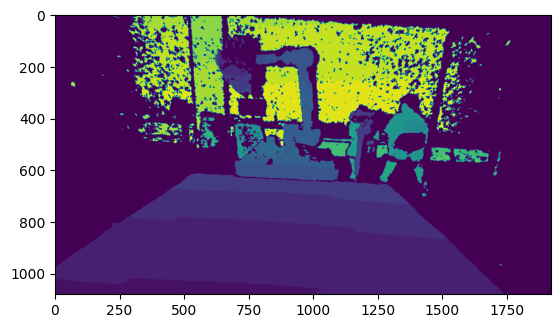

In [22]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
path = "/remote-home/liuym/data/0901/depth_to_rgb/frame_1693313100693747470_1.png"
img1 = cv2.imread(path, cv2.IMREAD_UNCHANGED)
print(img1.dtype)
print("max:", np.max(img1))
plt.imshow(img1)
plt.show()

uint8


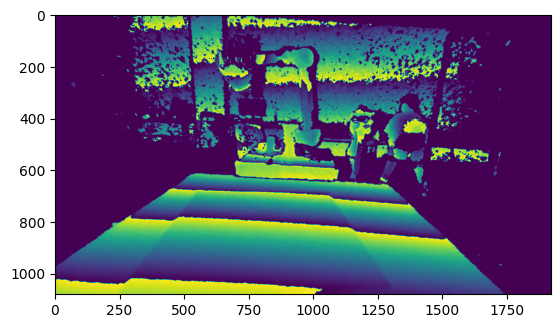

In [23]:
import matplotlib.pyplot as plt
path = "/remote-home/liuym/data/0901/depth_to_rgb/frame_1693313100693747470_0.png"
img0 = cv2.imread(path, cv2.IMREAD_UNCHANGED)
print(img0.dtype)
plt.imshow(img0)
plt.show()

5977


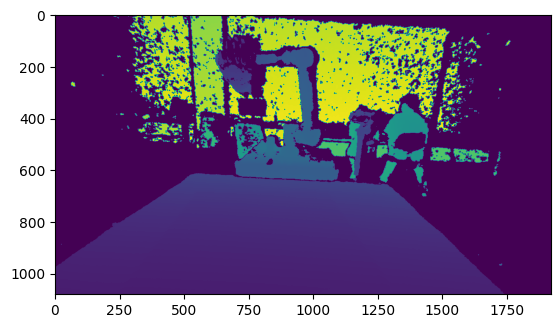

In [24]:
img = img0 + 2**8 * img1
print(np.max(img))
plt.imshow(img)
plt.show()

In [3]:
from transforms3d.quaternions import mat2quat
import numpy as np

mat = [[0.991325, 0.130305, -0.017191], 
       [0.030977, -0.358750, -0.932919],
       [-0.127731, 0.924294, -0.359675],
       ]
mat_base = [-0.048274, -0.859775, 0.508386, 
       0.937302, -0.214877, -0.274396, 
       0.345159, 0.463265, 0.816242, 
       ]
mat_origin = [-0.921508, -0.365140, 0.132274,
              -0.160531, 0.048001, -0.985863,
              0.353629, -0.929714, -0.102849]
transl = [-0.149010,-0.005023,2.092960]
mat = np.array(mat_origin).reshape(-1)
quat = mat2quat(mat)
print(quat)

[ 0.07688247  0.18257943 -0.71978427  0.66533032]


In [8]:

from transforms3d.affines import compose
# Align CAD model 
mat_origin = [-0.921508, -0.365140, 0.132274,
              -0.160531, 0.048001, -0.985863,
              0.353629, -0.929714, -0.102849]
transl = [-0.149010,-0.005023,2.092960]
mat = np.array(mat_origin).reshape(-1)
quat = mat2quat(mat)
print(quat)
align_affine = compose(T=transl, R=mat.reshape(3, 3), Z=np.ones(3))
print(align_affine) # cam_body -> world

[ 0.07688247  0.18257943 -0.71978427  0.66533032]
[[-0.921508 -0.36514   0.132274 -0.14901 ]
 [-0.160531  0.048001 -0.985863 -0.005023]
 [ 0.353629 -0.929714 -0.102849  2.09296 ]
 [ 0.        0.        0.        1.      ]]


In [14]:

from transforms3d.quaternions import quat2mat

# cam_base -> cam_body
cam0_body_pose = [-0.003945, -0.031956, -0.000522, 0.495797, -0.503967, 0.504645 , -0.495515]
cam0_transl = np.array(cam0_body_pose[:3])
cam0_quat = np.array(cam0_body_pose[3:]) # w, x, y, z
# cam0_quat = cam0_quat.transpose([-1, 0, 1, 2]) # x, y, z, w
cam0_affine = compose(T=cam0_transl, R=quat2mat(cam0_quat), Z=np.ones(3))

affine = np.linalg.inv(align_affine) @ np.linalg.inv(cam0_affine)
print(affine)

quat = mat2quat(affine[:3, :3]) 
print(quat)
transl = affine[:3, -1]
print(transl)






[[ 0.35672535  0.92121511  0.155271   -0.84732416]
 [-0.93025813  0.36554663 -0.03156013  1.89968208]
 [-0.08583305 -0.13318318  0.98736758  0.22593891]
 [ 0.          0.          0.          1.        ]]
[ 0.82304917 -0.03086784  0.07323488 -0.56238234]
[-0.84732416  1.89968208  0.22593891]
